In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load clean dataframe
df = pd.read_csv('cleaned_data.csv')

In [3]:
#Lets EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        720 non-null    object 
 1   company     720 non-null    object 
 2   year        720 non-null    int64  
 3   Price       720 non-null    float64
 4   kms_driven  720 non-null    float64
 5   fuel_type   720 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 33.9+ KB


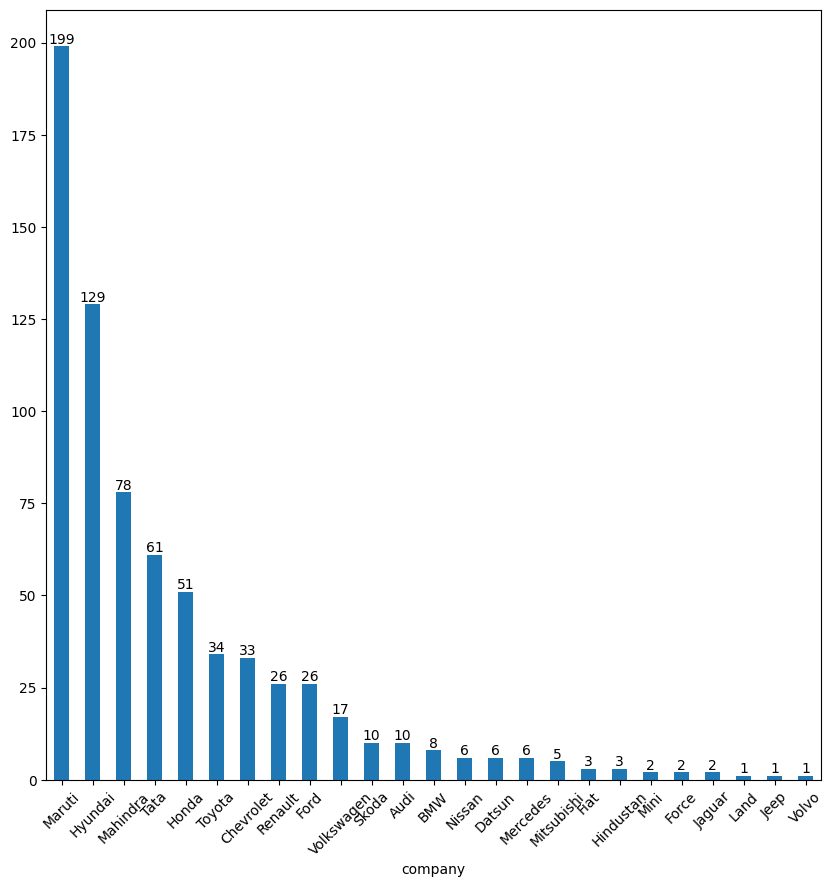

In [9]:
#Lets find count of cars by company
plt.figure(figsize=(10, 10))
counts = df['company'].value_counts()
ax = counts.plot(kind='bar')
# Add values on top of bars
for i, value in enumerate(counts):
    plt.text(i, value, str(value), 
             ha='center', va='bottom')
plt.xticks(rotation=45)
plt.show()

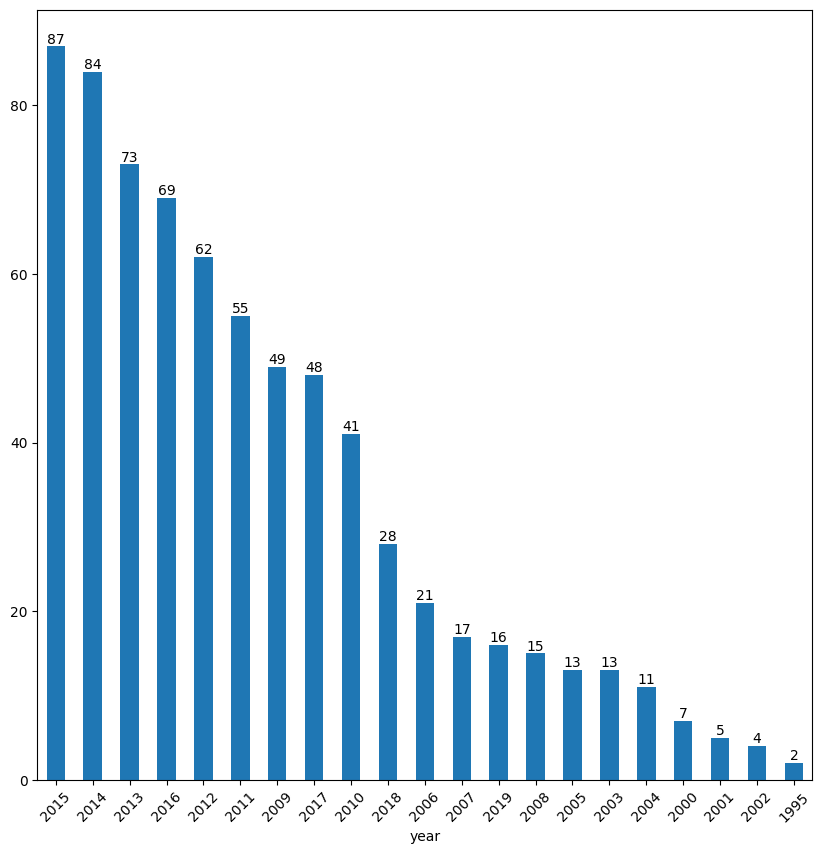

In [10]:
#Lets find count of cars by year
plt.figure(figsize=(10, 10))
counts = df['year'].value_counts()
ax = counts.plot(kind='bar')
# Add values on top of bars
for i, value in enumerate(counts):
    plt.text(i, value, str(value), 
             ha='center', va='bottom')
plt.xticks(rotation=45)
plt.show()

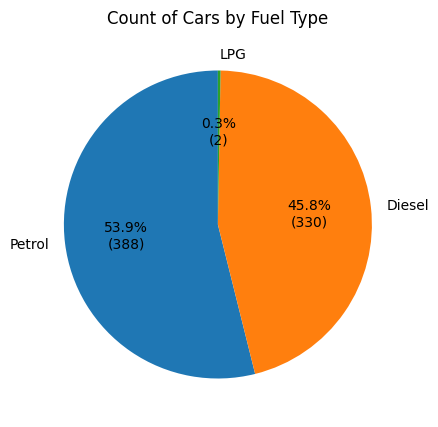

In [15]:

plt.figure(figsize=(5, 5))

counts = df['fuel_type'].value_counts()

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return my_format

ax = counts.plot(
    kind='pie',
    autopct=autopct_format(counts),
    startangle=90
)

plt.ylabel("")  # removes default ylabel
plt.title("Count of Cars by Fuel Type")
plt.show()

In [16]:
bins = [0, 25000, 50000, 100000, 150000, 200000]
labels = [
    "0-25k",
    "25k-50k",
    "50k-100k",
    "100k-150k",
    "150k-200k"
]

df['kms_group'] = pd.cut(
    df['kms_driven'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

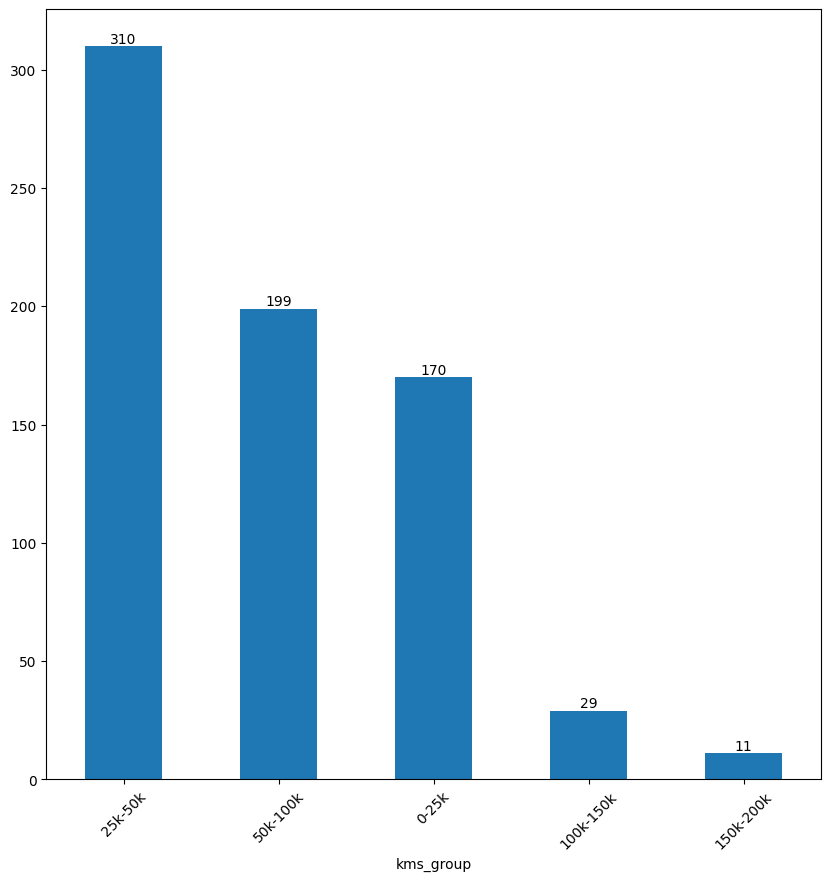

In [18]:
#Lets find count of cars by year
plt.figure(figsize=(10, 10))
counts = df['kms_group'].value_counts()
ax = counts.plot(kind='bar')
# Add values on top of bars
for i, value in enumerate(counts):
    plt.text(i, value, str(value), 
             ha='center', va='bottom')
plt.xticks(rotation=45)
plt.show()

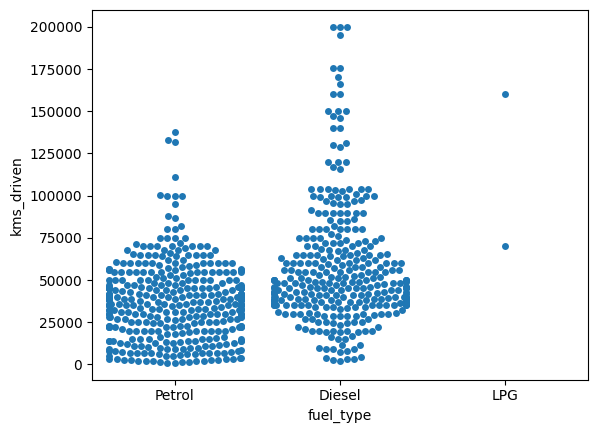

In [28]:
#12. Swarm Plot
sns.swarmplot(x='fuel_type', y='kms_driven', data=df)
plt.show()

In [25]:
#sorted(df['kms_driven'].unique())
#We found out that we must remove cars whose running is less than 1000 and more than 200000
df = df[(df['kms_driven'] >= 1000) & (df['kms_driven'] <= 200000)]

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 704 entries, 0 to 719
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   name        704 non-null    object  
 1   company     704 non-null    object  
 2   year        704 non-null    int64   
 3   Price       704 non-null    float64 
 4   kms_driven  704 non-null    float64 
 5   fuel_type   704 non-null    object  
 6   kms_group   704 non-null    category
dtypes: category(1), float64(2), int64(1), object(3)
memory usage: 39.4+ KB


In [29]:
# sorted(df['kms_driven'].unique())

In [30]:
#Save dataframe as csv file
df.to_csv('cleaned_data.csv', index = False)